In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("../data/telco_churn_cleaned.csv")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
TenureBucket            str
dtype: object

In [6]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
# total number of services subscribed
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                 'TechSupport', 'StreamingTV', 'StreamingMovies']

df['TotalServices'] = (df[service_cols] == 'Yes').sum(axis=1)

In [8]:
# average charge per service
df['AvgChargePerService'] = df['MonthlyCharges'] / (df['TotalServices'] + 1) 

In [9]:
df[['TotalServices', 'AvgChargePerService']].describe()

,TotalServices,AvgChargePerService
count,7043.000000,7043.000000
mean,2.037910,25.490020
std,1.847682,14.093315
min,0.000000,8.650000
25%,0.000000,18.025000
50%,2.000000,20.660000
75%,3.000000,27.425000
max,6.000000,77.900000


In [10]:
# IsNewCustomer flag
df['IsNewCustomer'] = (df['tenure'] <= 6).astype(int)

In [11]:
# HasMultipleServices flag
df['IsBundledCustomer'] = (df['TotalServices'] >= 3).astype(int)

In [12]:
# Contract risk flag
df['IsMonthToMonth'] = (df['Contract'] == 'Month-to-month').astype(int)

In [13]:
df[['IsNewCustomer', 'IsBundledCustomer', 'IsMonthToMonth']].sum()

IsNewCustomer        1481
IsBundledCustomer    2825
IsMonthToMonth       3875
dtype: int64

In [14]:
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes':1,'No':0})

In [15]:
df[binary_cols].head()

,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,1,0,0,1,0
1,0,0,1,0,0
2,0,0,1,1,1
3,0,0,0,0,0
4,0,0,1,1,1


In [19]:
cols_to_fix = ['MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

for col in cols_to_fix:
    df[col] = df[col].replace({'No internet service':'No','No phone service':'No'})

In [22]:
for col in cols_to_fix:
    df[col] = df[col].map({'Yes':1,'No':0})

In [23]:
df[cols_to_fix].head()

,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,0,0,1,0,0,0,0
1,0,1,0,1,0,0,0
2,0,1,1,0,0,0,0
3,0,1,0,1,1,0,0
4,0,0,0,0,0,0,0


In [24]:
df[cols_to_fix].isnull().sum()

MultipleLines       0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64

In [25]:
nominal_cols = ['gender','InternetService','Contract','PaymentMethod','TenureBucket']
df = pd.get_dummies(df,columns = nominal_cols, drop_first = True)

In [26]:
df.shape

(7043, 34)

In [27]:
df.columns.tolist()

['customerID',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'PaperlessBilling',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'TotalServices',
 'AvgChargePerService',
 'IsNewCustomer',
 'IsBundledCustomer',
 'IsMonthToMonth',
 'gender_Male',
 'InternetService_Fiber optic',
 'InternetService_No',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check',
 'TenureBucket_13-24',
 'TenureBucket_25-48',
 'TenureBucket_49-60',
 'TenureBucket_61-72']

In [28]:
df.columns = df.columns.str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

In [29]:
df.columns.tolist()

['customerID',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'PaperlessBilling',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'TotalServices',
 'AvgChargePerService',
 'IsNewCustomer',
 'IsBundledCustomer',
 'IsMonthToMonth',
 'gender_Male',
 'InternetService_Fiber_optic',
 'InternetService_No',
 'Contract_One_year',
 'Contract_Two_year',
 'PaymentMethod_Credit_card_automatic',
 'PaymentMethod_Electronic_check',
 'PaymentMethod_Mailed_check',
 'TenureBucket_13-24',
 'TenureBucket_25-48',
 'TenureBucket_49-60',
 'TenureBucket_61-72']

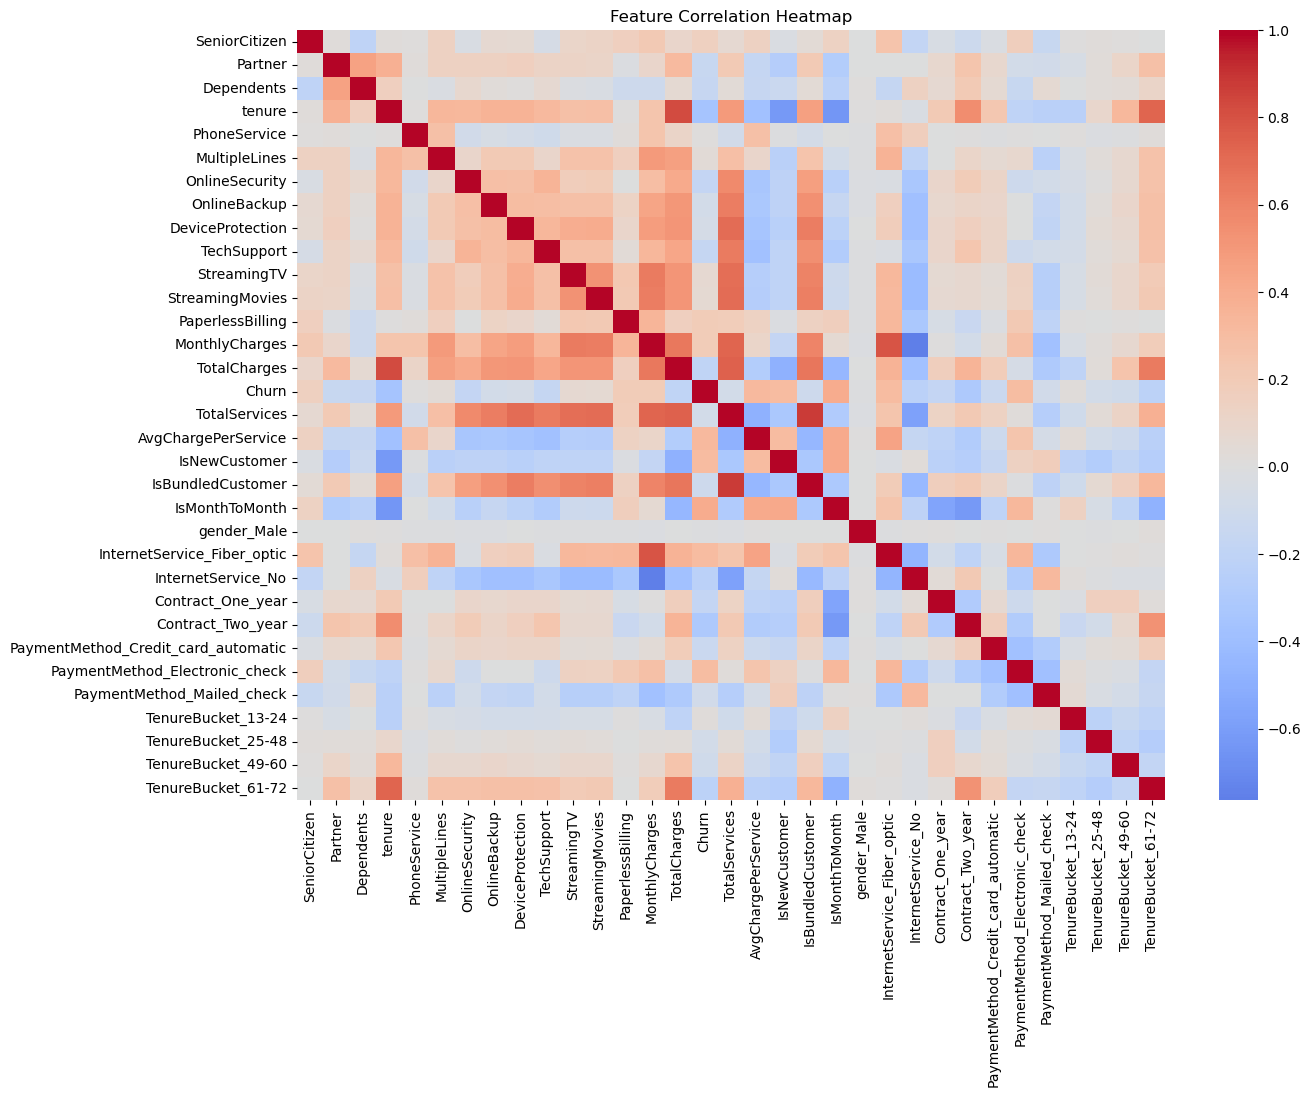

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.drop(columns=['customerID']).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

In [31]:
corr['Churn'].sort_values(ascending=False)

Churn                                  1.000000
IsMonthToMonth                         0.405103
AvgChargePerService                    0.319316
IsNewCustomer                          0.308539
InternetService_Fiber_optic            0.308020
PaymentMethod_Electronic_check         0.301919
MonthlyCharges                         0.193356
PaperlessBilling                       0.191825
SeniorCitizen                          0.150889
StreamingTV                            0.063228
StreamingMovies                        0.061382
MultipleLines                          0.040102
TenureBucket_13-24                     0.020308
PhoneService                           0.011942
gender_Male                           -0.008612
DeviceProtection                      -0.066160
TenureBucket_25-48                    -0.075312
OnlineBackup                          -0.082255
TotalServices                         -0.087698
PaymentMethod_Mailed_check            -0.091683
TenureBucket_49-60                    -0

In [32]:
df[['MonthlyCharges', 'TotalCharges', 'TotalServices', 'AvgChargePerService', 'tenure']].corr()

,MonthlyCharges,TotalCharges,TotalServices,AvgChargePerService,tenure
MonthlyCharges,1.000000,0.651174,0.724706,0.110679,0.247900
TotalCharges,0.651174,1.000000,0.744827,-0.274891,0.826178
TotalServices,0.724706,0.744827,1.000000,-0.486809,0.494263
AvgChargePerService,0.110679,-0.274891,-0.486809,1.000000,-0.372471
tenure,0.247900,0.826178,0.494263,-0.372471,1.000000
